# ⚽ 5.5 コンペティション事例で学ぶ軌道予測：Soccer Trajectory Prediction Challenge 2025

## 参考
*   Competition Homepage: https://sites.google.com/view/stp-challenge/
*   Github Page: https://github.com/open-starlab/STP-challenge-2025

## クレジット
*   Authors: Keisuke Fujii
*   Affiliation: Nagoya University
*   Last updated: 2025-12-07
*   License: CC BY 4.0


# このノートブックの実行手順

1. **必要なパッケージのインストール**
2. **GitHubリポジトリのクローン**
3. **モデルの学習**
4. **評価と可視化**


# Step 1: 必要なパッケージのインストール



In [ ]:
# 必要なパッケージをインストールします
!pip install gdown torch torchvision tqdm

# Step 2: GitHubリポジトリのクローン

In [ ]:
# Clone the repository containing additional scripts
!git clone https://github.com/open-starlab/STP-challenge-2025.git

# Move into the cloned repository
%cd STP-challenge-2025

Cloning into 'STP-challenge-2025'...
remote: Enumerating objects: 179, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 179 (delta 50), reused 54 (delta 18), pack-reused 67 (from 1)
Receiving objects: 100% (179/179), 56.34 MiB | 14.01 MiB/s, done.
Resolving deltas: 100% (65/65), done.
Updating files: 100% (49/49), done.
/content/STP-challenge-2025


(Option) Data download from google drive (1000 games)

In [ ]:
# !python download_from_gdrive.py --subpaths aeteam2024-cyrus2024

# Step 3: モデルの学習

Run the training script for 10 epochs with the RNN model.

Explanation of parameters:

--n_epoch 10: trains for 10 epochs.

--model RNN: specifies the model type as RNN.

In [ ]:
# Training the model using provided main.py script
# --burn_in 30: uses the first 30 frames as input (burn-in period).
# -t_step 60: predicts the next 60-30=30 frames.
# if you change the dataset, please delete the metadata.pkl
# if data_dir option is not used, only 10 samples from /robocup2d_data are used (default batch size: 64)
!python main.py --n_epoch 10 --model RNN --burn_in 30 -t_step 60 --Sanity # --batchsize 512 --data_dir ./downloaded_files/aeteam2024-cyrus2024

cuda is used
Creating metadata...
Metadata saved to ./metadata/metadata.pkl
train: 556 val:48 test: 52
num_workers:0
Modify_Velocity:True
/content/STP-challenge-2025/main.py:383: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tensor = torch.tensor(data, dtype=torch.float32)  # Shape: (agents, length, dim)
Velocity (Sanity Check)
Mean:
  Position Error: 4.95 ± 1.24
  Velocity Error: 0.47 ± 0.09
Endpoint:
  Position Error: 10.72 ± 2.59
  Velocity Error: 0.46 ± 0.11
model: ./weights/RNN_robocup2D/64_60
batchnorm = True
############################################################
epoch 1
########## lr 1.0000e-03 ##########
pretrain:False
Processing batches: 100% 9/9 [00:51<00:00,  5.77s/it]
Train:	 L_rec: 0.438| e_pos: 0.000 | e_vel: 0.436
Processing batches: 100% 1/1 [00:02

In [ ]:
# (option: using the trained model with 1000 files)
# Download the file from Google Drive
!gdown --fuzzy https://drive.google.com/file/d/1FY3kZiKxFe8GGh-g4UL--CtTMrrql6LU/view?usp=sharing

# Create the target directory
!mkdir -p weights/RNN_robocup2D/512_60_state_dict

# Move the downloaded file to the target directory and rename it
!mv 512_60_state_dict_best.pth weights/RNN_robocup2D/512_60_state_dict_best.pth

Downloading...
From: https://drive.google.com/uc?id=1FY3kZiKxFe8GGh-g4UL--CtTMrrql6LU
To: /content/STP-challenge-2025/512_60_state_dict_best.pth
100% 1.94M/1.94M [00:00<00:00, 217MB/s]


# Step 4: 評価と可視化

In [ ]:
# Testing with challenge data
!python main.py --model RNN --burn_in 30 -t_step 60 --challenge_data ./test_old/input # --batchsize 512

cuda is used
Loading metadata...
train: 556 val:48 test: 52
num_workers:0
Modify_Velocity:True
model: ./weights/RNN_robocup2D/64_60
batchnorm = True
############################################################
test sample
/content/STP-challenge-2025/main.py:383: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  tensor = torch.tensor(data, dtype=torch.float32)  # Shape: (agents, length, dim)
Time:	 1.034
Samples saved to ./results/test/submission


In [ ]:
# Evaluating with challenge procedure
!python example/evaluation.py --submit ./results/test/submission --gt ./test_old/gt --input ./test_old/input

Trajectory Prediction Evaluation Results:
Burn-in Steps: 0
Number of Evaluated Sequences: 3
Average Error (after burn-in): 5.9345
Endpoint Error: 10.4726


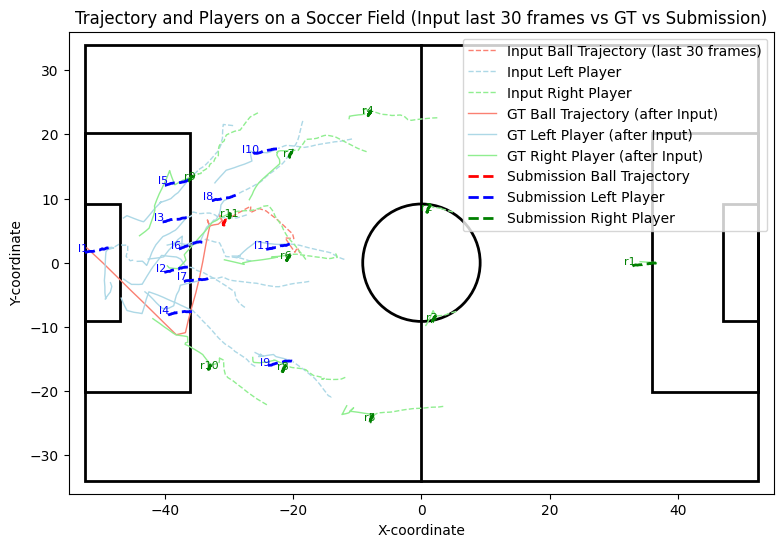

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Load the data from the submission CSV file (Prediction)
submission_df = pd.read_csv('./results/test/submission/01.csv')

# Load the input data
input_file_path = './test_old/input/01.csv'

# Load the true GT data (will be labeled as "GT" in the plot)
true_gt_file_path = './test_old/gt/01.csv'

Last_frames = 30

# Check if the input and true GT files exist before attempting to load
if os.path.exists(input_file_path) and os.path.exists(true_gt_file_path):
    input_df = pd.read_csv(input_file_path)
    true_gt_df = pd.read_csv(true_gt_file_path)

    # Determine the length of the input data
    input_length = len(input_df)

    # Determine the length of the submission data for slicing the GT data
    submission_length = len(submission_df)

    # Calculate the starting index for GT data after removing input length
    gt_start_index = input_length
    # Calculate the ending index for GT data to get a sequence of submission_length
    gt_end_index = gt_start_index + submission_length

    # Create a figure and axes for the soccer field
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw the soccer field outline
    ax.add_patch(plt.Rectangle((-52.5, -34), 105, 68, edgecolor='black', facecolor='none', linewidth=2))

    # Draw center circle
    ax.add_patch(plt.Circle((0, 0), 9.15, edgecolor='black', facecolor='none', linewidth=2))

    # Draw center line
    ax.plot([0, 0], [-34, 34], color='black', linewidth=2)

    # Draw penalty areas
    ax.add_patch(plt.Rectangle((-52.5, -20.15), 16.5, 40.3, edgecolor='black', facecolor='none', linewidth=2))
    ax.add_patch(plt.Rectangle((36, -20.15), 16.5, 40.3, edgecolor='black', facecolor='none', linewidth=2))

    # Draw goal areas
    ax.add_patch(plt.Rectangle((-52.5, -9.15), 5.5, 18.3, edgecolor='black', facecolor='none', linewidth=2))
    ax.add_patch(plt.Rectangle((47, -9.15), 5.5, 18.3, edgecolor='black', facecolor='none', linewidth=2))

    # Draw goals
    ax.add_patch(plt.Rectangle((-52.5, -3.66), 0, 7.32, edgecolor='black', facecolor='none', linewidth=2))
    ax.add_patch(plt.Rectangle((52.5, -3.66), 0, 7.32, edgecolor='black', facecolor='none', linewidth=2))

    # Plot the trajectory of the ball (Input data - last Last_frames, thin line)
    input_plot_start_index = len(input_df) - Last_frames
    if input_plot_start_index < 0:
        input_plot_start_index = 0 # Ensure we don't go below index 0
    input_ball_x = input_df['b_x'].values[input_plot_start_index:]
    input_ball_y = input_df['b_y'].values[input_plot_start_index:]
    ax.plot(input_ball_x, input_ball_y, linestyle='--', color='salmon', linewidth=1, label=f'Input Ball Trajectory (last {Last_frames} frames)')

    # Plot the players (Input data - last Last_frames, thin line)
    input_left_players_x = [col for col in input_df.columns if col.startswith('l') and col.endswith('_x')]
    input_left_players_y = [col for col in input_df.columns if col.startswith('l') and col.endswith('_y')]
    input_right_players_x = [col for col in input_df.columns if col.startswith('r') and col.endswith('_x')]
    input_right_players_y = [col for col in input_df.columns if col.startswith('r') and col.endswith('_y')]

    for i in range(len(input_left_players_x)):
        ax.plot(input_df[input_left_players_x[i]].values[input_plot_start_index:], input_df[input_left_players_y[i]].values[input_plot_start_index:], linestyle='--', color='lightblue', linewidth=1, label='Input Left Player' if i == 0 else "")

    for i in range(len(input_right_players_x)):
        ax.plot(input_df[input_right_players_x[i]].values[input_plot_start_index:], input_df[input_right_players_y[i]].values[input_plot_start_index:], linestyle='--', color='lightgreen', linewidth=1, label='Input Right Player' if i == 0 else "")

    # Plot the trajectory of the ball (GT data - starting after input length, same length as submission, thin solid line)
    gt_ball_x = true_gt_df['b_x'].values[gt_start_index:gt_end_index]
    gt_ball_y = true_gt_df['b_y'].values[gt_start_index:gt_end_index]
    ax.plot(gt_ball_x, gt_ball_y, linestyle='-', color='salmon', linewidth=1, label=f'GT Ball Trajectory (after Input)')

    # Plot the players (GT data - starting after input length, same length as submission, thin solid line)
    true_gt_left_players_x = [col for col in true_gt_df.columns if col.startswith('l') and col.endswith('_x')]
    true_gt_left_players_y = [col for col in true_gt_df.columns if col.startswith('l') and col.endswith('_y')]
    true_gt_right_players_x = [col for col in true_gt_df.columns if col.startswith('r') and col.endswith('_x')]
    true_gt_right_players_y = [col for col in true_gt_df.columns if col.startswith('r') and col.endswith('_y')]

    for i in range(len(true_gt_left_players_x)):
        ax.plot(true_gt_df[true_gt_left_players_x[i]].values[gt_start_index:gt_end_index], true_gt_df[true_gt_left_players_y[i]].values[gt_start_index:gt_end_index], linestyle='-', color='lightblue', linewidth=1, label='GT Left Player (after Input)' if i == 0 else "")

    for i in range(len(true_gt_right_players_x)):
        ax.plot(true_gt_df[true_gt_right_players_x[i]].values[gt_start_index:gt_end_index], true_gt_df[true_gt_right_players_y[i]].values[gt_start_index:gt_end_index], linestyle='-', color='lightgreen', linewidth=1, label='GT Right Player (after Input)' if i == 0 else "")


    # Plot the trajectory of the ball (Submission data - thick dotted line)
    submission_ball_x = submission_df['b_x'].values
    submission_ball_y = submission_df['b_y'].values
    ax.plot(submission_ball_x, submission_ball_y, linestyle='--', color='red', linewidth=2, label='Submission Ball Trajectory')

    # Plot the players (Submission data - thick dotted line)
    submission_left_players_x = [col for col in submission_df.columns if col.startswith('l') and col.endswith('_x')]
    submission_left_players_y = [col for col in submission_df.columns if col.startswith('l') and col.endswith('_y')]
    submission_right_players_x = [col for col in submission_df.columns if col.startswith('r') and col.endswith('_x')]
    submission_right_players_y = [col for col in submission_df.columns if col.startswith('r') and col.endswith('_y')]

    for i in range(len(submission_left_players_x)):
        ax.plot(submission_df[submission_left_players_x[i]].values, submission_df[submission_left_players_y[i]].values, linestyle='--', color='blue', linewidth=2, label='Submission Left Player' if i == 0 else "")
        # Add player number/ID text (using the last known position from submission data)
        player_id = submission_left_players_x[i].replace('_x', '')
        last_x = submission_df[submission_left_players_x[i]].iloc[-1]
        last_y = submission_df[submission_left_players_y[i]].iloc[-1]
        ax.text(last_x, last_y, player_id, color='blue', fontsize=8, ha='center', va='bottom')


    for i in range(len(submission_right_players_x)):
        ax.plot(submission_df[submission_right_players_x[i]].values, submission_df[submission_right_players_y[i]].values, linestyle='--', color='green', linewidth=2, label='Submission Right Player' if i == 0 else "")
        # Add player number/ID text (using the last known position from submission data)
        player_id = submission_right_players_x[i].replace('_x', '')
        last_x = submission_df[submission_right_players_x[i]].iloc[-1]
        last_y = submission_df[submission_right_players_y[i]].iloc[-1]
        ax.text(last_x, last_y, player_id, color='green', fontsize=8, ha='center', va='bottom')


    # Set limits and aspect ratio
    ax.set_xlim([-55, 55])
    ax.set_ylim([-36, 36])
    ax.set_aspect('equal', adjustable='box')

    # Add title and labels
    ax.set_title(f'Trajectory and Players on a Soccer Field (Input last {Last_frames} frames vs GT vs Submission)')
    ax.set_xlabel('X-coordinate')
    ax.set_ylabel('Y-coordinate')

    # Add legend
    ax.legend()

    # Show the plot
    plt.show()
else:
    if not os.path.exists(input_file_path):
        print(f"Input file not found at: {input_file_path}")
    if not os.path.exists(true_gt_file_path):
        print(f"True GT file not found at: {true_gt_file_path}")

In [ ]:
print(f"Length of GT data: {len(true_gt_left_players_x)}")
print(f"Length of Submission data: {len(submission_left_players_x)}")

Length of GT data: 11
Length of Submission data: 11
